In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import nltk
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

In [2]:
df = pd.read_csv("..\Datasets\IMDB_dataset.csv")
df.head(10)

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive
5,"Probably my all-time favorite movie, a story o...",positive
6,I sure would like to see a resurrection of a u...,positive
7,"This show was an amazing, fresh & innovative i...",negative
8,Encouraged by the positive comments about this...,negative
9,If you like original gut wrenching laughter yo...,positive


In [3]:
df.sample(10)

,review,sentiment
35125,This movie has been promoting in everywhere in...,negative
33994,One of the first things I noticed that allowed...,negative
4177,I have been a fan of Pushing Daisies since the...,positive
26851,I rarely make these comments but I felt compel...,negative
15741,"I found Grey Garden's to be a gripping film, a...",positive
45706,"If Jean Renoir's first film ""Whirlpool of Fate...",positive
41100,I thought this movie was fun. I have never rea...,positive
25975,If it had been made 2 years later it would hav...,positive
15890,The Merchant of Venice 8/10<br /><br />(This r...,positive
38668,Dirty Dancing follows the story of Frances 'Ba...,positive


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


In [5]:
# changing the ojbect to lowercase and remove the sepcial characters
def preprocess_text(text):
    text = str(text).lower()
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', '', text).strip()  # ' text '
    return text

df['review'] = df['review'].apply(preprocess_text)
df.head()

,review,sentiment
0,oneoftheotherreviewershasmentionedthatafterwat...,positive
1,awonderfullittleproductionthefilmingtechniquei...,positive
2,ithoughtthiswasawonderfulwaytospendtimeonatooh...,positive
3,basicallytheresafamilywherealittleboyjakethink...,negative
4,pettermatteisloveinthetimeofmoneyisavisuallyst...,positive


In [6]:
nltk.download('stopwords')  # downloading the nltk stopwords

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\aravi\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [7]:
stop_words = set(stopwords.words('english'))

In [8]:
# function to remove stopwords
def remove_stopwords(text):
    words = re.findall(r'\w+', text.lower()) # tokenize text
    filtered_words = [word for word in words if word not in stop_words]
    return "".join(filtered_words)

# apply stopword removal
df['review'] = df['review'].apply(remove_stopwords)
df.head()

,review,sentiment
0,oneoftheotherreviewershasmentionedthatafterwat...,positive
1,awonderfullittleproductionthefilmingtechniquei...,positive
2,ithoughtthiswasawonderfulwaytospendtimeonatooh...,positive
3,basicallytheresafamilywherealittleboyjakethink...,negative
4,pettermatteisloveinthetimeofmoneyisavisuallyst...,positive


In [9]:
df['sentiment'].unique()

array(['positive', 'negative'], dtype=object)

In [10]:
# change the sentiment to 1 and 0
df['sentiment'] = df['sentiment'].map({'positive' : 1, "negative" : 0})
df.head()

,review,sentiment
0,oneoftheotherreviewershasmentionedthatafterwat...,1
1,awonderfullittleproductionthefilmingtechniquei...,1
2,ithoughtthiswasawonderfulwaytospendtimeonatooh...,1
3,basicallytheresafamilywherealittleboyjakethink...,0
4,pettermatteisloveinthetimeofmoneyisavisuallyst...,1


In [11]:
# apply TF-IDF Vectorization with a limited feature size to reduce memory usage
vectorizer = TfidfVectorizer(
    max_features= 10000,
    min_df=5,
    max_df=0.8,
    ngram_range=(1,2)
)
X = vectorizer.fit_transform(df['review'])

In [12]:
x = X
y = df['sentiment']

# split the data into training and testing set

X_train, X_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [13]:
# train a random forest classifier
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


Accuracy: 50.00%

Classification Report:
               precision    recall  f1-score   support

           0       0.50      1.00      0.67      5000
           1       0.00      0.00      0.00      5000

    accuracy                           0.50     10000
   macro avg       0.25      0.50      0.33     10000
weighted avg       0.25      0.50      0.33     10000



C:\Users\aravi\AppData\Roaming\Python\Python310\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\aravi\AppData\Roaming\Python\Python310\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\aravi\AppData\Roaming\Python\Python310\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capital

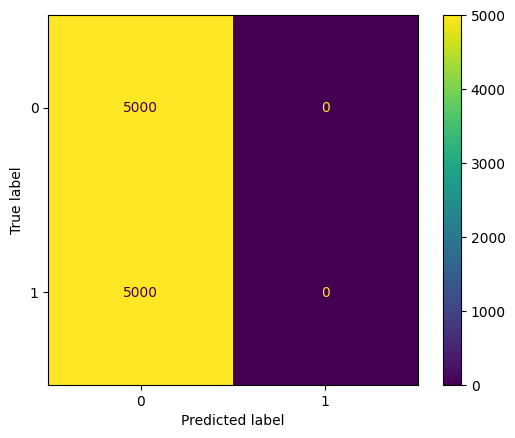

In [14]:
# predict the sentiment of the test set
y_pred = clf.predict(X_test)

# calculate the accuracy of the model 
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy: {:.2f}%".format(accuracy*100))

# classification report
print("\nClassification Report:\n", classification_report(y_test, y_pred))

#Confusion matrix display
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm)
disp.plot()
plt.show()

In [15]:
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression(max_iter=1000)

Accuracy: 50.00%

Classification Report:
               precision    recall  f1-score   support

           0       0.50      1.00      0.67      5000
           1       0.00      0.00      0.00      5000

    accuracy                           0.50     10000
   macro avg       0.25      0.50      0.33     10000
weighted avg       0.25      0.50      0.33     10000



C:\Users\aravi\AppData\Roaming\Python\Python310\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\aravi\AppData\Roaming\Python\Python310\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\aravi\AppData\Roaming\Python\Python310\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capital

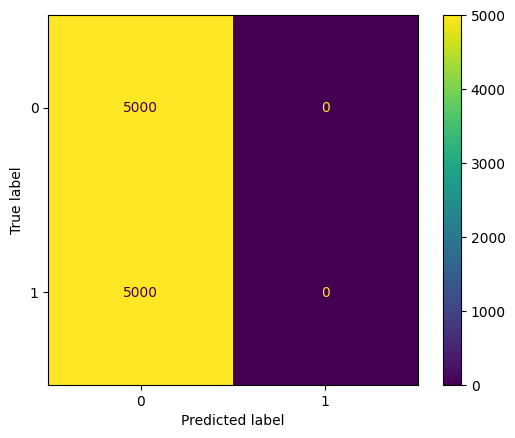

In [16]:
clf.fit(X_train, y_train)

# predict the sentiment of the test set
y_pred = clf.predict(X_test)

# calculate the accuracy of the model 
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy: {:.2f}%".format(accuracy*100))

# classification report
print("\nClassification Report:\n", classification_report(y_test, y_pred))

#Confusion matrix display
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm)
disp.plot()
plt.show()

In [18]:
def predict_sentiment(text):
    text = preprocess_text(text)
    text = remove_stopwords(text)
    text_vector = vectorizer.transform([text])
    predicted = clf.predict(text_vector)
    return "Positive" if predicted[0] == 1 else "Negative"

reviews = [
    "Amazing movie with a great storyline!",
    "i didn't enjoy this film at all.",
    "It was okay, nothing special"
]

for review in reviews:
    print(f"Review: {review}.\nPredicted Sentiment: {predict_sentiment(review)}")

Review: Amazing movie with a great storyline!.
Predicted Sentiment: Negative
Review: i didn't enjoy this film at all..
Predicted Sentiment: Negative
Review: It was okay, nothing special.
Predicted Sentiment: Negative
